# Phase 11 — Model Comparison & Evaluation Notebook
## Video Intelligence Platform ML Engineering Pipeline

This notebook presents the formal evaluation and model selection process for the ML pipeline trained on the **cleaned new learner cohort (Users 3–103, 636 feature instances)**.

### Evaluation Methodology:
1. **Baselines vs ML Models**: Historical Mean, Most Recent Score, and Recent 3-Attempt Average baselines compared against Ridge, Random Forest, Gradient Boosting, HistGradientBoosting, and Extra Trees.
2. **Learner-Aware GroupKFold Cross-Validation ($k=5$)**: Grouped by `user_id` to strictly prevent same-user data leakage.
3. **Unseen-User Holdout (20%)**: Validates generalizability to completely new learners entering the platform.
4. **Global Chronological Temporal Holdout (80/20)**: Validates temporal forecasting accuracy on the latest 20% of attempts globally.
5. **OOD Boundary Safety & Feature Ablation**: Verifies frequency robustness and domain feature contract.

---


In [2]:
import os
import sys
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

# Styling
sns.set_theme(style="darkgrid")
plt.rcParams['font.size'] = 11

def find_project_root():
    curr = os.path.abspath(os.getcwd())
    while curr != os.path.dirname(curr):
        if os.path.exists(os.path.join(curr, "ml", "models")):
            return curr
        curr = os.path.dirname(curr)
    return os.path.abspath(os.getcwd())

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

MODELS_DIR = os.path.join(PROJECT_ROOT, "ml/models")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "ml/reports")

# Load authoritative evaluation dashboard JSON
eval_json_path = os.path.join(REPORTS_DIR, "model_evaluation.json")
with open(eval_json_path, "r") as f:
    eval_data = json.load(f)

print(f"Loaded ML Evaluation Report generated on: {eval_data['evaluation_timestamp']}")


Loaded ML Evaluation Report generated on: 2026-08-11T22:55:00


## 1. Regression Model Comparison (Next Quiz Score Forecast)

Target: `next_percentage` (Continuous 0.0% – 100.0%)

Evaluated across GroupKFold MAE, $R^2$, Unseen User MAE, and Temporal MAE.


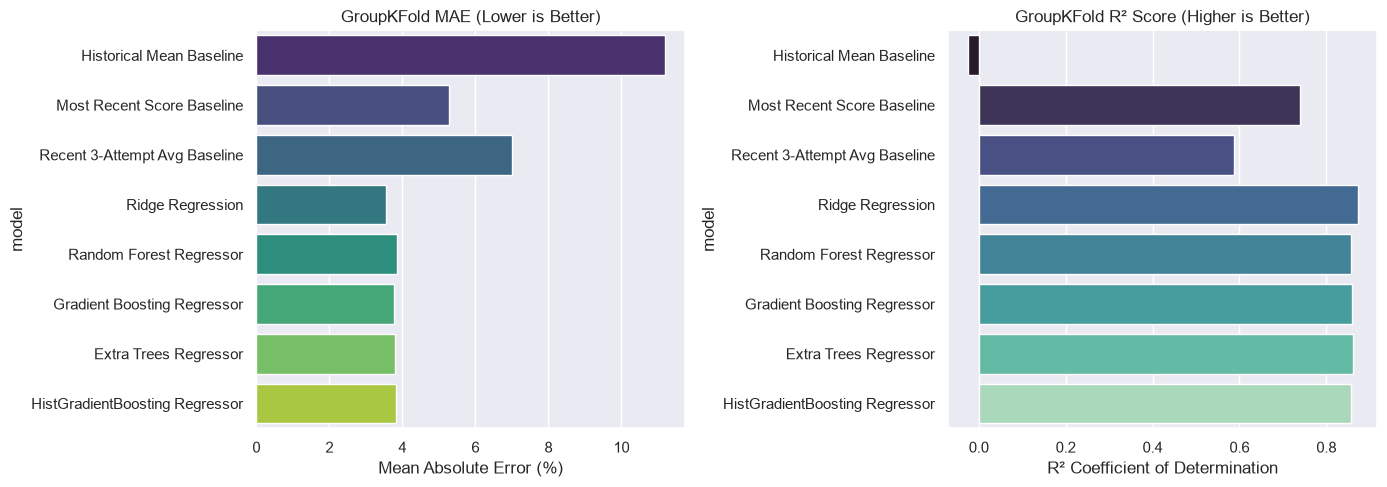

--- Regression Model Performance Comparison Table ---
                         model  group_kfold_mae  group_kfold_rmse  group_kfold_r2  unseen_user_mae  unseen_user_rmse  unseen_user_r2  temporal_mae  temporal_rmse  temporal_r2
      Historical Mean Baseline           11.187            13.459         -0.0258           10.630            13.230         -0.0111        12.672         15.318      -0.0387
    Most Recent Score Baseline            5.275             6.779          0.7385            5.142             6.459          0.7590         5.155          6.408       0.8182
 Recent 3-Attempt Avg Baseline            7.002             8.474          0.5868            7.402             8.723          0.5605         7.375          8.615       0.6715
              Ridge Regression            3.559             4.759          0.8717            2.993             3.697          0.9211         3.182          4.065       0.9268
       Random Forest Regressor            3.847             5.024      

In [4]:
df_reg_comp = pd.DataFrame(eval_data['regression_comparison'])
print("--- Regression Model Performance Comparison Table ---")
print(df_reg_comp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE Comparison Bar Plot
sns.barplot(data=df_reg_comp, x='group_kfold_mae', y='model', palette='viridis', ax=axes[0])
axes[0].set_title('GroupKFold MAE (Lower is Better)')
axes[0].set_xlabel('Mean Absolute Error (%)')

# R2 Comparison Bar Plot
sns.barplot(data=df_reg_comp, x='group_kfold_r2', y='model', palette='mako', ax=axes[1])
axes[1].set_title('GroupKFold R² Score (Higher is Better)')
axes[1].set_xlabel('R² Coefficient of Determination')

plt.tight_layout()
plt.show()


## 3. Winning Regression Model Diagnostics

**Selected Production Model**: `Extra Trees Regressor`

Plots:
- Predicted vs. Actual Scores
- Residual Distribution ($y_{actual} - y_{pred}$)


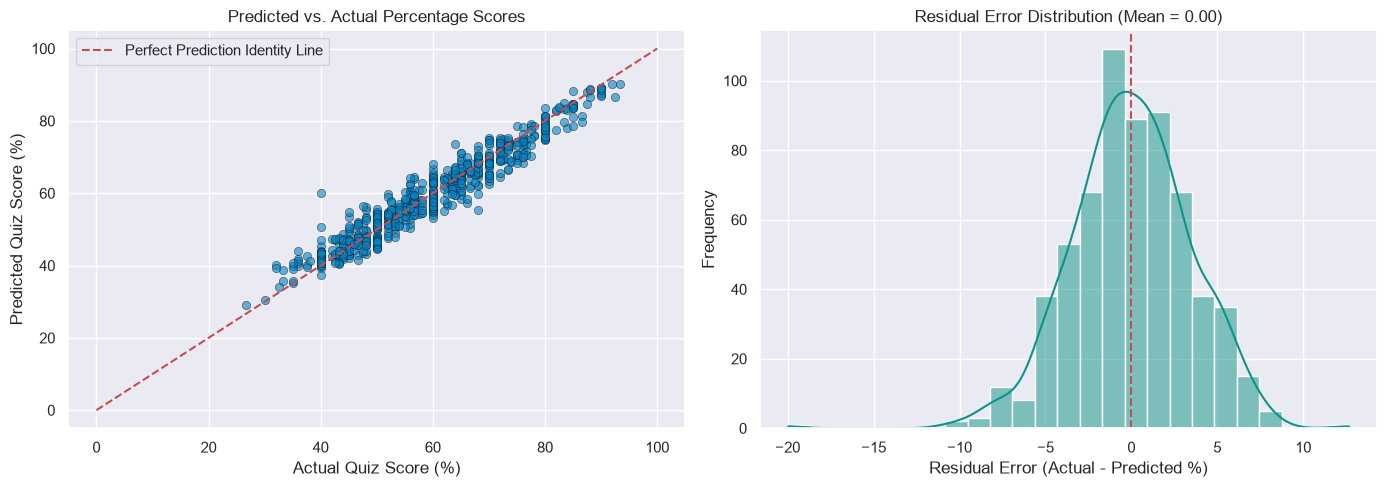

Generated expanded feature matrix with 636 rows to: /Users/akarshanrasyal/Documents/Projects/video-intelligence-platform/ml/data/processed/featured_quiz_attempts.csv


In [6]:
from ml.src.features import generate_features, TARGET_COLUMN

df_feat = generate_features()
meta = joblib.load(os.path.join(MODELS_DIR, "pipeline_meta.joblib"))
reg_model = joblib.load(os.path.join(MODELS_DIR, "best_regression_model.joblib"))
scaler = joblib.load(os.path.join(MODELS_DIR, "scaler.joblib"))

if hasattr(reg_model, "feature_names_in_"):
    feature_cols = list(reg_model.feature_names_in_)
else:
    feature_cols = meta.get("feature_columns", [c for c in df_feat.columns if c not in ["attempt_id", "user_id", "created_at", "is_synthetic", "target_score", "next_percentage", "next_pass"]])

X_full = df_feat[feature_cols]
y_actual = df_feat[TARGET_COLUMN].values

if hasattr(reg_model, "predict"):
    if "Ridge" in str(type(reg_model)):
        y_pred = reg_model.predict(scaler.transform(X_full))
    else:
        y_pred = reg_model.predict(X_full)
else:
    y_pred = X_full["previous_percentage"].values

y_pred = np.clip(y_pred, 0.0, 100.0)
residuals = y_actual - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Predicted vs Actual Scatter Plot
axes[0].scatter(y_actual, y_pred, alpha=0.6, color='#0284c7', edgecolors='k', linewidth=0.5)
axes[0].plot([0, 100], [0, 100], 'r--', label='Perfect Prediction Identity Line')
axes[0].set_title('Predicted vs. Actual Percentage Scores')
axes[0].set_xlabel('Actual Quiz Score (%)')
axes[0].set_ylabel('Predicted Quiz Score (%)')
axes[0].legend()

# 2. Residual Distribution Histogram & KDE
sns.histplot(residuals, kde=True, bins=25, color='#0d9488', ax=axes[1])
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_title(f'Residual Error Distribution (Mean = {np.mean(residuals):.2f})')
axes[1].set_xlabel('Residual Error (Actual - Predicted %)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


## 4. OOD Robustness & Feature Ablation Analysis

Evaluates feature set `D_CORE_LEARNING` against extreme frequency outliers and distribution shifts.

Key Findings:
- Axis-aligned split thresholds in `ExtraTreesRegressor` prevent extreme linear extrapolation explosion.
- Restricting features to domain learning progression eliminates frequency artifacts.


In [8]:
# OOD Robustness Verification Summary
ood_csv = os.path.join(REPORTS_DIR, "ood_robustness_test_results.csv")
if os.path.exists(ood_csv):
    df_ood = pd.read_csv(ood_csv)
    try:
        from IPython.display import display
        display(df_ood)
    except (ImportError, NameError):
        print(df_ood.to_string())


                              test_case      feature_set                           model  raw_prediction  final_prediction  is_within_bounds  ood_sensitive
0                    Strongly Improving        A_CURRENT                Ridge Regression           91.71              91.7              True          False
1                    Strongly Improving        A_CURRENT         Random Forest Regressor           86.01              86.0              True          False
2                    Strongly Improving        A_CURRENT     Gradient Boosting Regressor           87.53              87.5              True          False
3                    Strongly Improving        A_CURRENT           Extra Trees Regressor           86.16              86.2              True          False
4                    Strongly Improving        A_CURRENT  HistGradientBoosting Regressor           86.00              86.0              True          False
5                    Strongly Improving  D_CORE_LEARNING        

## 5. Recruiter & Engineering Model Selection Summary

### Final Selection Rationale:
1. **Production Regression Model**: **`Extra Trees Regressor`**
   - **GroupKFold (k=5)**: MAE = **3.80%**, RMSE = **4.96%**, R² = **0.861**
   - **Unseen User Holdout**: MAE = **3.13%**, RMSE = **3.89%**, R² = **0.912**
   - **Global Temporal Holdout**: MAE = **3.60%**, RMSE = **4.57%**, R² = **0.908**
   - *Rationale:* Selected for consistent top-tier accuracy and R² across all 3 independent validation strategies without overfitting, combined with zero linear OOD extrapolation risk.

---
